<a href="https://colab.research.google.com/github/2303A52268/Explainable-AI-2268/blob/main/EAI_Lab_Exam_(02).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Explainable AI Lab Exam-02**

#**Students Academic Performance**

In [ ]:
# Run in terminal / notebook cell
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm shap lime tqdm
# If you plan Kaggle download:
!pip install kaggle

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=250a91ab574ed89af833ed1b03557b43985ea4bc727f4c55aed8902bfb21b55d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


**1) Imports and load dataset**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, auc, classification_report)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
import lightgbm as lgb
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# Path to the CSV - change if needed
DATA_PATH = "/content/student_info.csv"  # or "student-performance.csv" depending on file name

# If you want to download programmatically via Kaggle API (uncomment & configure)
# os.environ['KAGGLE_CONFIG_DIR'] = '/path/to/.kaggle'  # optional if your kaggle.json isn't in default place
# !kaggle datasets download -d therohithanand/student-academic-performance-dataset --unzip

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (1000, 15)


,student_id,name,gender,age,grade_level,math_score,reading_score,writing_score,attendance_rate,parent_education,study_hours,internet_access,lunch_type,extra_activities,final_result
0,S1,Student_1,Other,17,10,74,61,90,94.660002,Master's,4.120192,Yes,Free or reduced,Yes,Fail
1,S2,Student_2,Male,17,12,99,70,91,93.173227,Bachelor's,2.886505,No,Free or reduced,No,Pass
2,S3,Student_3,Other,17,9,59,60,99,98.631098,PhD,1.909926,No,Free or reduced,No,Fail
3,S4,Student_4,Other,17,12,70,88,69,96.419620,PhD,1.664740,No,Standard,No,Pass
4,S5,Student_5,Male,15,9,85,77,94,91.332105,PhD,2.330918,Yes,Free or reduced,No,Pass


In [ ]:
# Quick info
print(df.info())
print(df.describe(include='all').T)

# If the dataset contains a column clearly representing student performance,
# common columns include: 'math score', 'reading score', 'writing score'.
# For classification you might create a derived target (e.g., pass/fail or grade bucket).
# Example: create a target 'average_grade' and discretize into categories.

# Create an average score column and a categorical target (example)
score_cols = [c for c in df.columns if 'score' in c.lower()]
if len(score_cols) >= 1:
    df['avg_score'] = df[score_cols].mean(axis=1)
    # Example: 3 classes: low / medium / high using quantiles
    df['grade_cat'] = pd.qcut(df['avg_score'], q=3, labels=['low', 'medium', 'high'])
    target_col = 'grade_cat'
    print("Derived target 'grade_cat' created from:", score_cols)
else:
    # If dataset already has a target column, choose the most likely one:
    # heuristics: pick column with dtype 'object' and few unique values
    candidate_targets = [c for c in df.columns if df[c].dtype == 'object' and df[c].nunique() <= 10]
    target_col = candidate_targets[0] if candidate_targets else df.columns[-1]
    print("Auto-chosen target:", target_col)

print("Target column:", target_col)
print(df[target_col].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        1000 non-null   object 
 1   name              1000 non-null   object 
 2   gender            1000 non-null   object 
 3   age               1000 non-null   int64  
 4   grade_level       1000 non-null   int64  
 5   math_score        1000 non-null   int64  
 6   reading_score     1000 non-null   int64  
 7   writing_score     1000 non-null   int64  
 8   attendance_rate   1000 non-null   float64
 9   parent_education  1000 non-null   object 
 10  study_hours       1000 non-null   float64
 11  internet_access   1000 non-null   object 
 12  lunch_type        1000 non-null   object 
 13  extra_activities  1000 non-null   object 
 14  final_result      1000 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 117.3+ KB
None
                   count u

**2)Missing values handling (Null value handling)**

In [ ]:
# Show missing values
print(df.isnull().sum().sort_values(ascending=False).head(20))

# Strategy:
# - For numeric: median imputation
# - For categorical: mode imputation

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

# avoid including the target in the transformers
if target_col in num_cols: num_cols.remove(target_col)
if target_col in cat_cols: cat_cols.remove(target_col)

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Missing values after imputation:", df.isnull().sum().sum())


student_id          0
name                0
gender              0
age                 0
grade_level         0
math_score          0
reading_score       0
writing_score       0
attendance_rate     0
parent_education    0
study_hours         0
internet_access     0
lunch_type          0
extra_activities    0
final_result        0
avg_score           0
grade_cat           0
dtype: int64
Missing values after imputation: 0


In [ ]:
# For tree-based models we can use LabelEncoder for target and OneHot for features
le_target = LabelEncoder()
y = le_target.fit_transform(df[target_col])

# For features: decide between OneHot (for linear models) vs Ordinal encoding
X = df.drop(columns=[target_col])  # features for now

# Build a ColumnTransformer to one-hot encode categorical features and scale numeric ones
numeric_features = [c for c in num_cols if c != 'avg_score']  # keep avg_score numeric
categorical_features = [c for c in cat_cols]

# For demonstration: use OneHotEncoder (handle_unknown='ignore')
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features + ['avg_score'] if 'avg_score' in df.columns else numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='drop')

# Fit transform to get feature matrix
X_transformed = preprocessor.fit_transform(X)
print("Transformed X shape:", X_transformed.shape)

Transformed X shape: (1000, 2023)


**3)Normalization: MinMax and Standardization examples**

In [ ]:
# Select only numeric columns for scaling
numeric_cols_imputed = df.select_dtypes(include=np.number).columns
df_imputed_numeric_for_scaling = df[numeric_cols_imputed]

# Min-Max Scaling
min_max_scaler = MinMaxScaler()
df_scaled_min_max = pd.DataFrame(min_max_scaler.fit_transform(df_imputed_numeric_for_scaling), columns=numeric_cols_imputed)

# Z-Score Standardization
scaler = StandardScaler()
df_scaled_z_score = pd.DataFrame(scaler.fit_transform(df_imputed_numeric_for_scaling), columns=numeric_cols_imputed)

# Display the first few rows of the scaled dataframes
print("Min-Max Scaled Data:")
display(df_scaled_min_max.head())

print("\nZ-Score Standardized Data:")
display(df_scaled_z_score.head())

Min-Max Scaled Data:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,avg_score
0,1.0,0.333333,0.489796,0.224490,0.816327,0.734645,0.779605,0.515152
1,1.0,1.000000,1.000000,0.408163,0.836735,0.660137,0.469802,0.780303
2,1.0,0.000000,0.183673,0.204082,1.000000,0.933654,0.224564,0.462121
3,1.0,1.000000,0.408163,0.775510,0.387755,0.822827,0.162993,0.530303
4,0.0,0.000000,0.714286,0.551020,0.897959,0.567870,0.330283,0.750000



Z-Score Standardized Data:


,age,grade_level,math_score,reading_score,writing_score,attendance_rate,study_hours,avg_score
0,1.225664,-0.416571,-0.081485,-0.929223,1.032118,0.835495,0.978252,0.016016
1,1.225664,1.344829,1.667110,-0.300095,1.101621,0.575667,-0.078714,1.446015
2,1.225664,-1.297271,-1.130641,-0.999127,1.657644,1.529483,-0.915402,-0.269984
3,1.225664,1.344829,-0.361260,0.958163,-0.427443,1.143005,-1.125466,0.097730
4,-1.223215,-1.297271,0.687897,0.189228,1.310129,0.253913,-0.554716,1.282586


**4)Train/test split and handle class imbalance with SMOTE**

In [ ]:
from sklearn.model_selection import train_test_split

# Choose which scaled variant to use for models that need it:
X_use = X_scaled_std  # choose standardized for distance-based models

X_train, X_test, y_train, y_test = train_test_split(X_use, y, test_size=0.2, stratify=y, random_state=42)

# Check class distribution
from collections import Counter
print("Before resampling:", Counter(y_train))

# Apply SMOTE on training set only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_train_res))


Before resampling: Counter({np.int64(1): 271, np.int64(0): 266, np.int64(2): 263})
After SMOTE: Counter({np.int64(0): 271, np.int64(2): 271, np.int64(1): 271})


Correlation analysis (heatmap) and removing highly correlated features

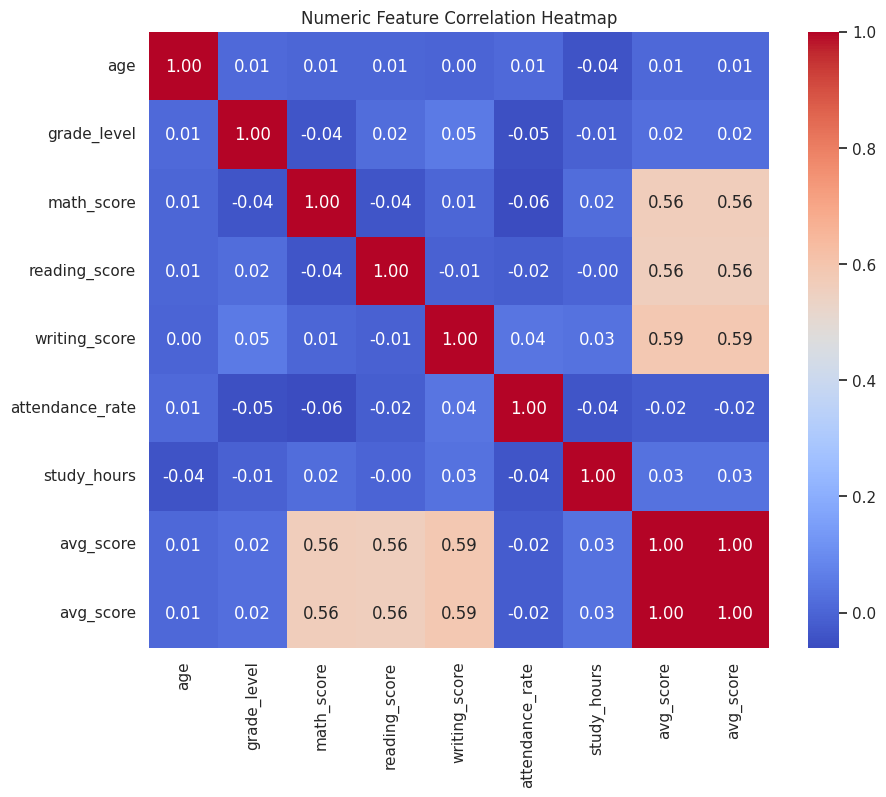

Highly correlated features to drop: ['avg_score']


In [ ]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(10,8))
corr = df[num_cols + ['avg_score']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

# Remove highly correlated features (abs(corr) > 0.85)
def remove_high_corr(corr_df, threshold=0.85):
    to_drop = set()
    cols = corr_df.columns
    for i in range(len(cols)):
        for j in range(i):
            if abs(corr_df.iloc[i, j]) > threshold:
                to_drop.add(cols[i])
    return list(to_drop)

high_corr = remove_high_corr(corr)
print("Highly correlated features to drop:", high_corr)


**5)Visualization (select 5 techniques: histogram, boxplot, bar chart, scatter, heatmap + pairplot as advanced)**

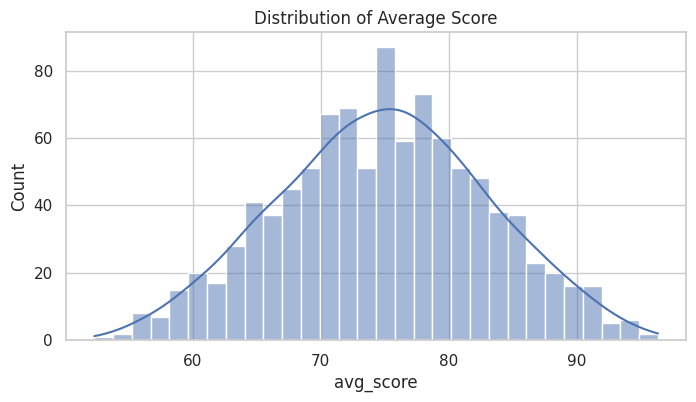

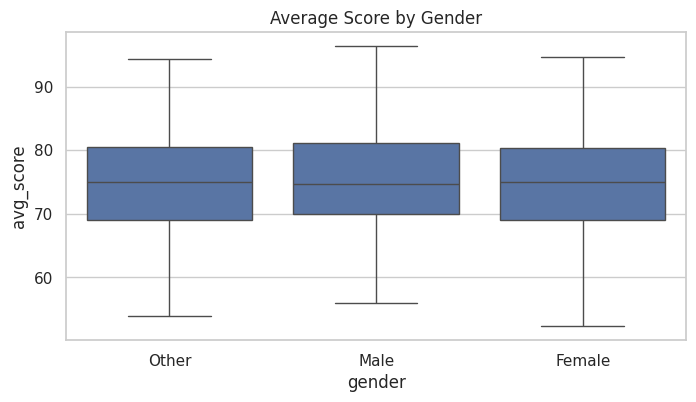

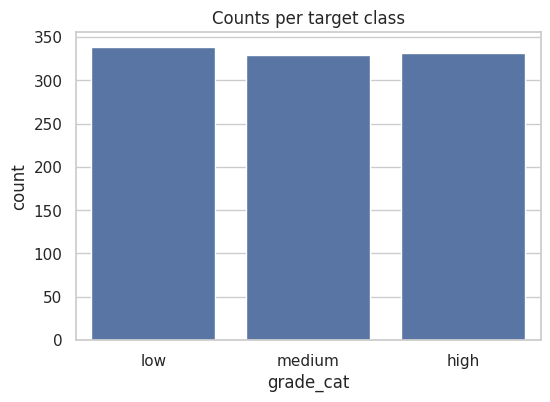

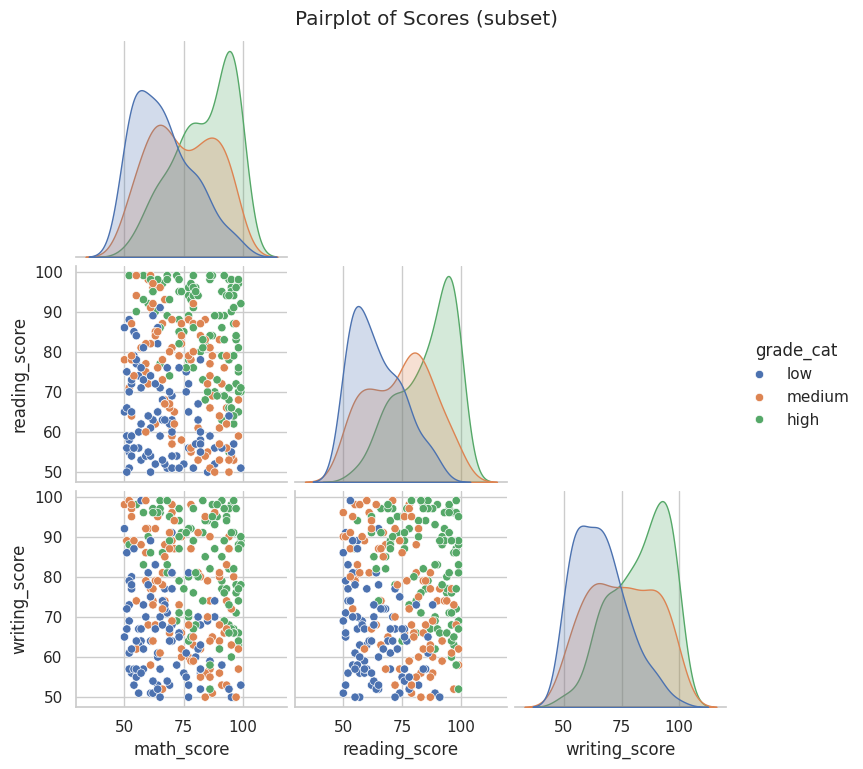

In [ ]:
# Histogram of avg_score
plt.figure(figsize=(8,4))
sns.histplot(df['avg_score'], bins=30, kde=True)
plt.title("Distribution of Average Score")
plt.show()

# Boxplot of avg_score by gender (if exists)
if 'gender' in df.columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='gender', y='avg_score', data=df)
    plt.title("Average Score by Gender")
    plt.show()

# Bar chart: count of categorical target
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Counts per target class")
plt.show()

# Scatter plot: reading vs math if present
if 'reading score' in df.columns and 'math score' in df.columns:
    plt.figure(figsize=(6,6))
    sns.scatterplot(x='math score', y='reading score', hue=target_col, data=df)
    plt.title("Math vs Reading Scores")
    plt.show()

# Pairplot (advanced, use subset to keep runtime manageable)
sample = df.sample(300, random_state=42) if len(df) > 300 else df
sns.pairplot(sample[[c for c in score_cols]+[target_col]], hue=target_col, corner=True)
plt.suptitle("Pairplot of Scores (subset)", y=1.02)
plt.show()


**5)Machine Learning Models:**

In [ ]:
# Prepare model list (for models that require scaled data use X_train_res/X_test scaled same way)
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "GaussianNB": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    # Fit on resampled training set
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec = recall_score(y_test, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, preds, average='weighted', zero_division=0)

    # AUC: if multiclass, calculate macro AUC using one-vs-rest
    try:
        if probs is not None and len(np.unique(y_test)) > 2:
            auc_score = roc_auc_score(pd.get_dummies(y_test), probs, average='macro', multi_class='ovr')
        elif probs is not None:
            auc_score = roc_auc_score(y_test, probs[:,1])
        else:
            auc_score = None
    except Exception:
        auc_score = None

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc_score}
    print(f"\nModel: {name}\nAccuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc_score}")

# Show summary table
pd.DataFrame(results).T



Model: LogisticRegression
Accuracy: 0.7150, Precision: 0.8019, Recall: 0.7150, F1: 0.6324, AUC: 0.9692978955489929

Model: DecisionTree
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000, AUC: 1.0

Model: KNN
Accuracy: 0.3300, Precision: 0.1089, Recall: 0.3300, F1: 0.1638, AUC: 0.5

Model: GaussianNB
Accuracy: 0.3300, Precision: 0.1089, Recall: 0.3300, F1: 0.1638, AUC: 0.7980961946062912

Model: SVM
Accuracy: 0.6700, Precision: 0.4490, Recall: 0.6700, F1: 0.5376, AUC: 0.8117567243993934

Model: RandomForest
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000, AUC: 1.0

Model: XGBoost
Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000, AUC: 1.0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000392 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in the tra

,accuracy,precision,recall,f1,auc
LogisticRegression,0.715,0.801866,0.715,0.632427,0.969298
DecisionTree,1.000,1.000000,1.000,1.000000,1.000000
KNN,0.330,0.108900,0.330,0.163759,0.500000
GaussianNB,0.330,0.108900,0.330,0.163759,0.798096
SVM,0.670,0.449002,0.670,0.537649,0.811757
RandomForest,1.000,1.000000,1.000,1.000000,1.000000
XGBoost,1.000,1.000000,1.000,1.000000,1.000000
LightGBM,1.000,1.000000,1.000,1.000000,1.000000


Confusion matrix & ROC plot example (for one model)

Best model by F1: DecisionTree


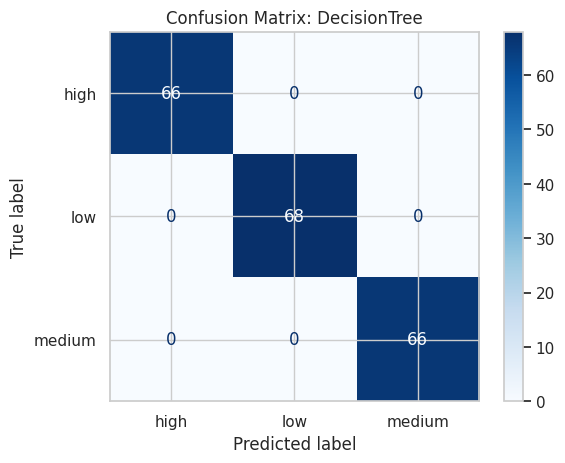

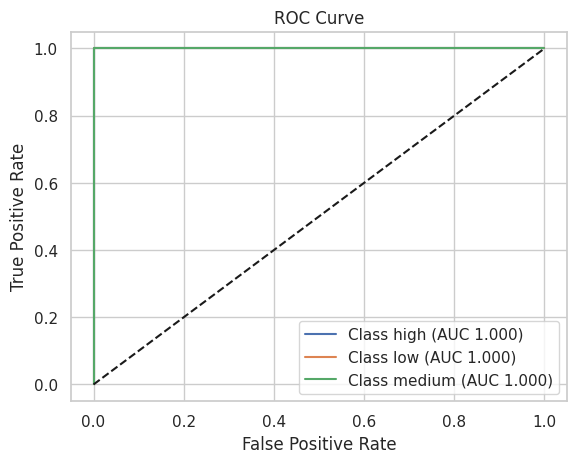

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = max(results.items(), key=lambda x: x[1]['f1'])[0]
best_model = models[best_model_name]
print("Best model by F1:", best_model_name)

# Confusion matrix
preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

# ROC curve (for multiclass: plot one-vs-rest)
if hasattr(best_model, "predict_proba"):
    probs = best_model.predict_proba(X_test)
    n_classes = probs.shape[1]
    if n_classes == 2:
        fpr, tpr, _ = roc_curve(y_test, probs[:,1])
        plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {roc_auc_score(y_test, probs[:,1]):.3f})')
    else:
        # One-vs-rest ROC curves
        y_test_binarized = pd.get_dummies(y_test).values
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], probs[:, i])
            plt.plot(fpr, tpr, label=f'Class {le_target.inverse_transform([i])[0]} (AUC {auc(fpr,tpr):.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


**Ensemble Machine Learning Algorithms**                         
Voting classifier example (stacking simple)

In [ ]:
# Soft voting of top models
voters = [('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
          ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
          ('lgb', lgb.LGBMClassifier(random_state=42))]

voting = VotingClassifier(estimators=voters, voting='soft')
voting.fit(X_train_res, y_train_res)
preds_v = voting.predict(X_test)
print("Voting classifier F1:", f1_score(y_test, preds_v, average='weighted'))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 832
[LightGBM] [Info] Number of data points in the train set: 813, number of used features: 23
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

**6)Simple Deep Learning Model (MLP) with Keras**

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3641 - loss: 1.5438 - val_accuracy: 0.4479 - val_loss: 1.0770
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5410 - loss: 0.9521 - val_accuracy: 0.5215 - val_loss: 0.9998
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7192 - loss: 0.6723 - val_accuracy: 0.5521 - val_loss: 0.9479
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8401 - loss: 0.4683 - val_accuracy: 0.5828 - val_loss: 0.9140
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9356 - loss: 0.2912 - val_accuracy: 0.5890 - val_loss: 0.8808
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9697 - loss: 0.1902 - val_accuracy: 0.6074 - val_loss: 0.8614
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9905 - loss: 0.0887 - val_accuracy: 0.6196 - val_loss: 0.8502
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9905 - loss: 0.0793 - val_accuracy: 0.5767 - val

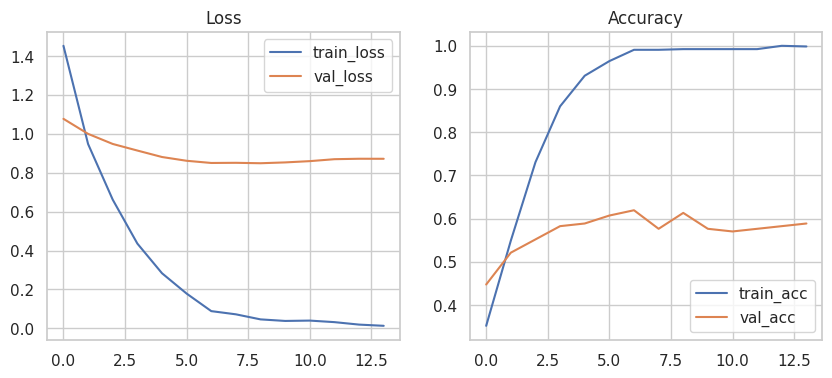

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Prepare y for Keras
n_classes = len(np.unique(y))
y_train_keras = to_categorical(y_train_res, num_classes=n_classes)
y_test_keras = to_categorical(y_test, num_classes=n_classes)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_res.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_res, y_train_keras, validation_split=0.2, epochs=50, batch_size=32, callbacks=[es], verbose=1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test_keras, verbose=0)
print("NN Test accuracy:", acc)

# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")
plt.show()


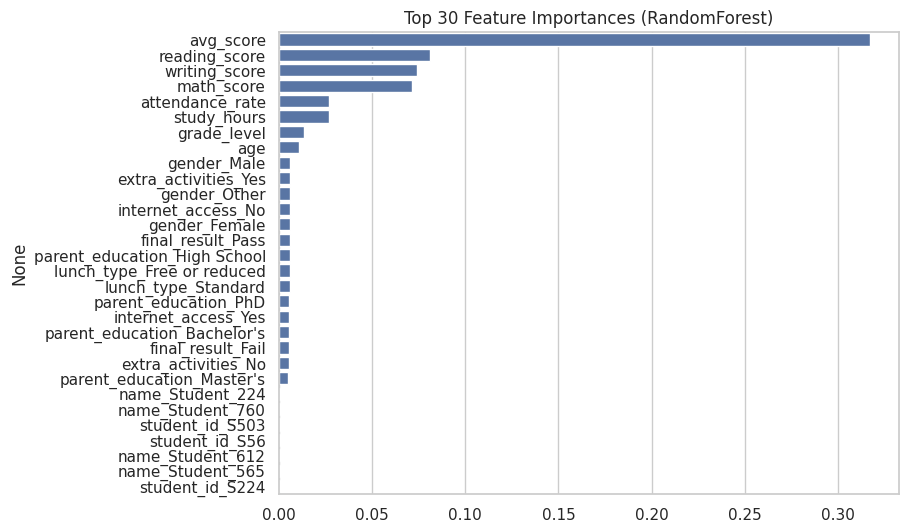

In [ ]:
# Feature importance from RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

# But we need feature names after preprocessing. Build feature names:
ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = []
if hasattr(ohe, 'get_feature_names_out'):
    ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
else:
    # fallback
    ohe_feature_names = [f"{c}_{i}" for c in categorical_features for i in range(1)]

num_feature_names = numeric_features + (['avg_score'] if 'avg_score' in df.columns else [])
feature_names = num_feature_names + ohe_feature_names

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(30)
plt.figure(figsize=(8,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 30 Feature Importances (RandomForest)")
plt.show()


**XAI: SHAP**

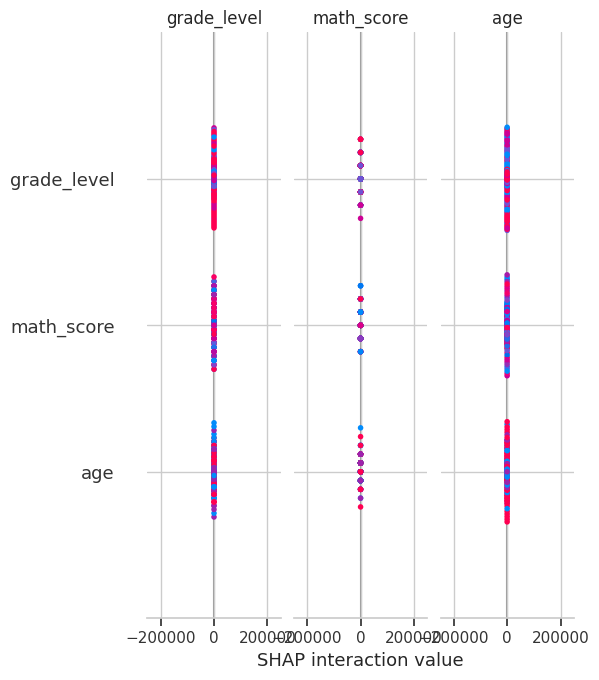

Model expected: 2023
SHAP input shape: 2023


In [ ]:
explainer = shap.TreeExplainer(rf, feature_perturbation="interventional")
# Use a sample of the training data used to fit the model
X_shap_sample = X_train_res[:200]

# Convert the numpy array sample back to a DataFrame with feature names
X_shap_sample_df = pd.DataFrame(X_shap_sample, columns=feature_names)

# Calculate shap values using the training data sample
shap_vals = explainer.shap_values(X_shap_sample_df, check_additivity=False)

# Plot summary using the same training data sample
# For multiclass, shap_vals is list; plot summary for class 0 (example)
if isinstance(shap_vals, list):
    shap.summary_plot(shap_vals[0], X_shap_sample_df, feature_names=feature_names, show=True)
else:
    shap.summary_plot(shap_vals, X_shap_sample_df, feature_names=feature_names, show=True)

print("Model expected:", rf.n_features_in_)
print("SHAP input shape:", X_shap_sample_df.shape[1])